In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.integrate import odeint

import os
import time


In [2]:

def Kerr_system(N, Delta, K, Epsilon):
    a = destroy(N) 
    """
Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        
    Regresa 
        Hamiltoniano: del sistema para un oscilador de Kerr 

     Hamiltoniano Kerr Oscillator de acuerdo al paper de Zhang2021:
         Detuning         (omega_d)
         No linealidad de Keer  (U)
         Squeezing              (G)
    """

    H = (
        - Delta*a.dag()*a               
        +  0.5*K* a.dag()*a.dag() *a*a       
        + 0.25*Epsilon* (a.dag()*a.dag() + a*a) 
        )
    
    return H
    
def Kerr_Diag(N, Delta, K, Epsilon, Jump_ops):
 
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa
        Eigenvalores del sistema.
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)
    L = liouvillian(H, Jump_ops)
    eigs = L.eigenenergies()

    return eigs

def Kerr_evo(N, Delta, K, Epsilon, t, init_rho, Jump_ops, Expected_ops):
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        t: array tipo linspace() de los valores del tiempo
        init_rho: Matriz de densidad inicial
        Jump_ops: array de los operadores de salto
        Expected_ops: array de los operadores que buscamos obtener su valor esperado
    
    Regresa 
        Estados evolucionados para cada paso de tiempo
        Evolución del valor de expectacion de los Expect_ops
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)


    evo = mesolve(H, init_rho, t, Jump_ops, e_ops = Expect_ops)

    return evo 

    



In [21]:
# -----------------------Parametros-------------------------------
N = [20,40,60,80,100]              # dim Hilbert space
# Loss 
g = 1        
K_list = np.array(
    [1/15, 1/30, 1/60, 1/75]     # Interaction, Kerr NL
    )             
Delta = 0                         # Detuning 
epsi_list = np.linspace(-2,2,200)    # Squeezing


# ------------------------------ CACHE ------------------------------
cache_folder = '2photon'
os.makedirs(cache_folder, exist_ok=True)
cache_file = os.path.join(cache_folder, 'NvsEpsi_data.npz')
# ------------------------------------------------------------------------------------------
if os.path.exists(cache_file):
    print("Cargando resultados desde caché...")
    data = np.load(cache_file, allow_pickle=True)

    # Acceso directo a los arrays
    n_ss_array = data['n_ss']  # Shape: (len(N), len(K_list), len(epsi_list))
    N_saved = data['N']
    K_saved = data['K_list']
    epsi_saved = data['epsi_list']
    print("----- O.o -----")

else:
    print("Calculando (esto puede tomar un momento)...") #------------------------------
    start_time = time.time()
    

    n_ss_all = np.zeros((len(N), len(K_list), len(epsi_list)))
    
    for i, d in enumerate(N):
        a = destroy(d)
        n = a.dag() * a
        salto = [
            np.sqrt(g) * a * a,
        ]
        
        for j, K in enumerate(K_list):
            print(f"d={d}, K={K:.4f}" + '\n')
            
            for k, e in enumerate(epsi_list):
                H = Kerr_system(d, Delta, K, e)
                rho_ss = steadystate(H, salto)    
                n_ss = expect(n, rho_ss)
                
                n_ss_all[i, j, k] = n_ss
                
                if k < 5:
                    print(
                        rf"eps={e:.3f}, "
                        f"<n>={n_ss:.4f}, "
                        f"Tr={rho_ss.tr():.8f}, "
                        f"Tr^2={(rho_ss*rho_ss).tr():.8f}, "
                        f"minEig={np.min(rho_ss.eigenenergies()):.3e}"
                    )
            print('\n')
    
    elapsed_time = time.time() - start_time
    print(f"Tiempo de cálculo: {elapsed_time:.2f} segundos")
    
    # Guardar en formato npz comprimido
    np.savez_compressed(
        cache_file,
        n_ss=n_ss_all,
        N=np.array(N),
        K_list=K_list,
        epsi_list=epsi_list,
        g=g,
        Delta=Delta
    )
    print(f"Datos guardados en {cache_file}")

Cargando resultados desde caché...
----- O.o -----


4


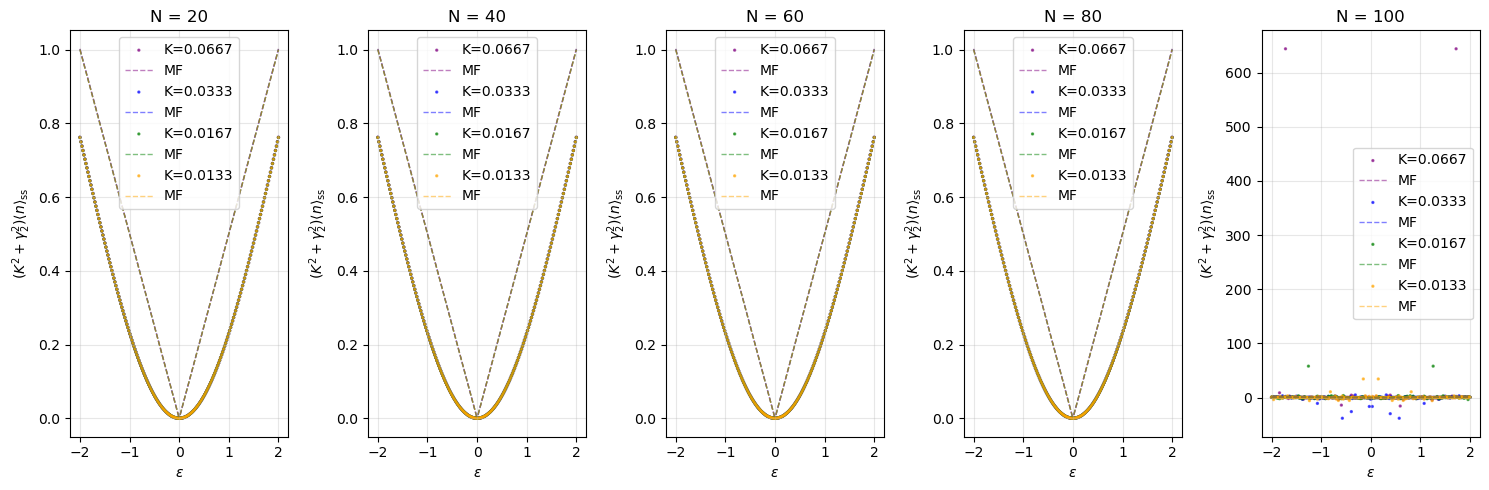

In [23]:
#---------- Mean Field --------------------------------------
n_mf = []
for k in K_list:
    mf = []
    for e in epsi_list:
        
        r = e**2 * (k**2 + g**2) + 4* g**2 * Delta**2
        n_mfx = k * Delta + 0.5 * np.sqrt(r)
        mf.append(n_mfx) 
    n_mf.append(np.array(mf))  
print(len(n_mf))
#------------------------------------------------------------
"""
Para la grafica en el eje x seria mi epsi_list y el eje y es K*n_1values
"""
fig, axes = plt.subplots(1, len(N), figsize=(15, 5))
colors = ['purple', 'blue', 'green', 'orange']

for idx_d, (ax, d) in enumerate(zip(axes, N)):
    for i, K in enumerate(K_list):
        ax.scatter(epsi_list, (K**2 + g**2) * n_ss_array[idx_d, i, :], 
                  c=colors[i % len(colors)], s=2, 
                  label=f"K={K:.4f}", ls= '-.', alpha=0.6
                  )
        ax.plot(epsi_list, n_mf[i], 
                c=colors[i % len(colors)], lw=1, 
                linestyle='--', label='MF', alpha=0.5
               )
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$(K^2 + \gamma_2^2)\langle n\rangle_{\rm ss}$")
    ax.set_title(f"N = {d}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('2photon/n_vs_epsilon.pdf', dpi=300)
plt.show()



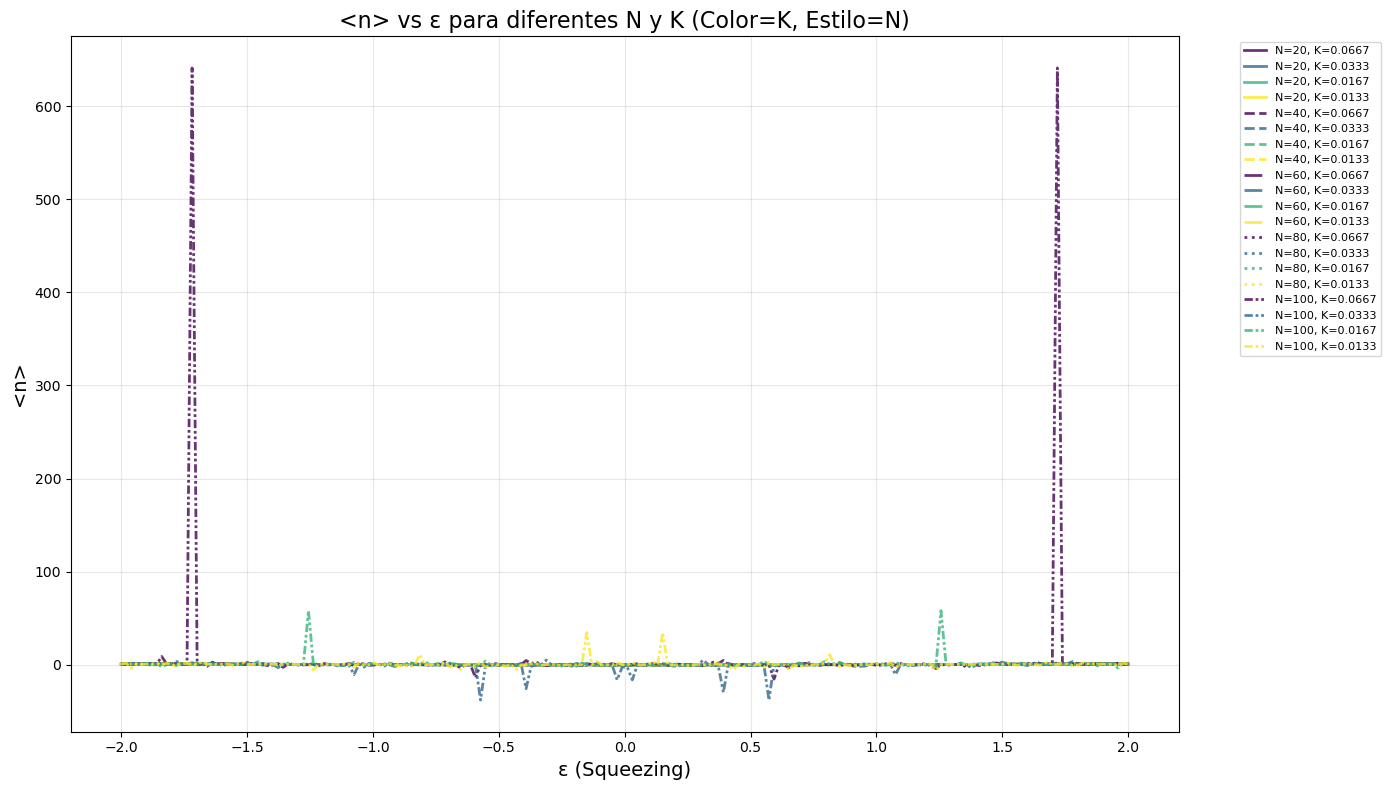

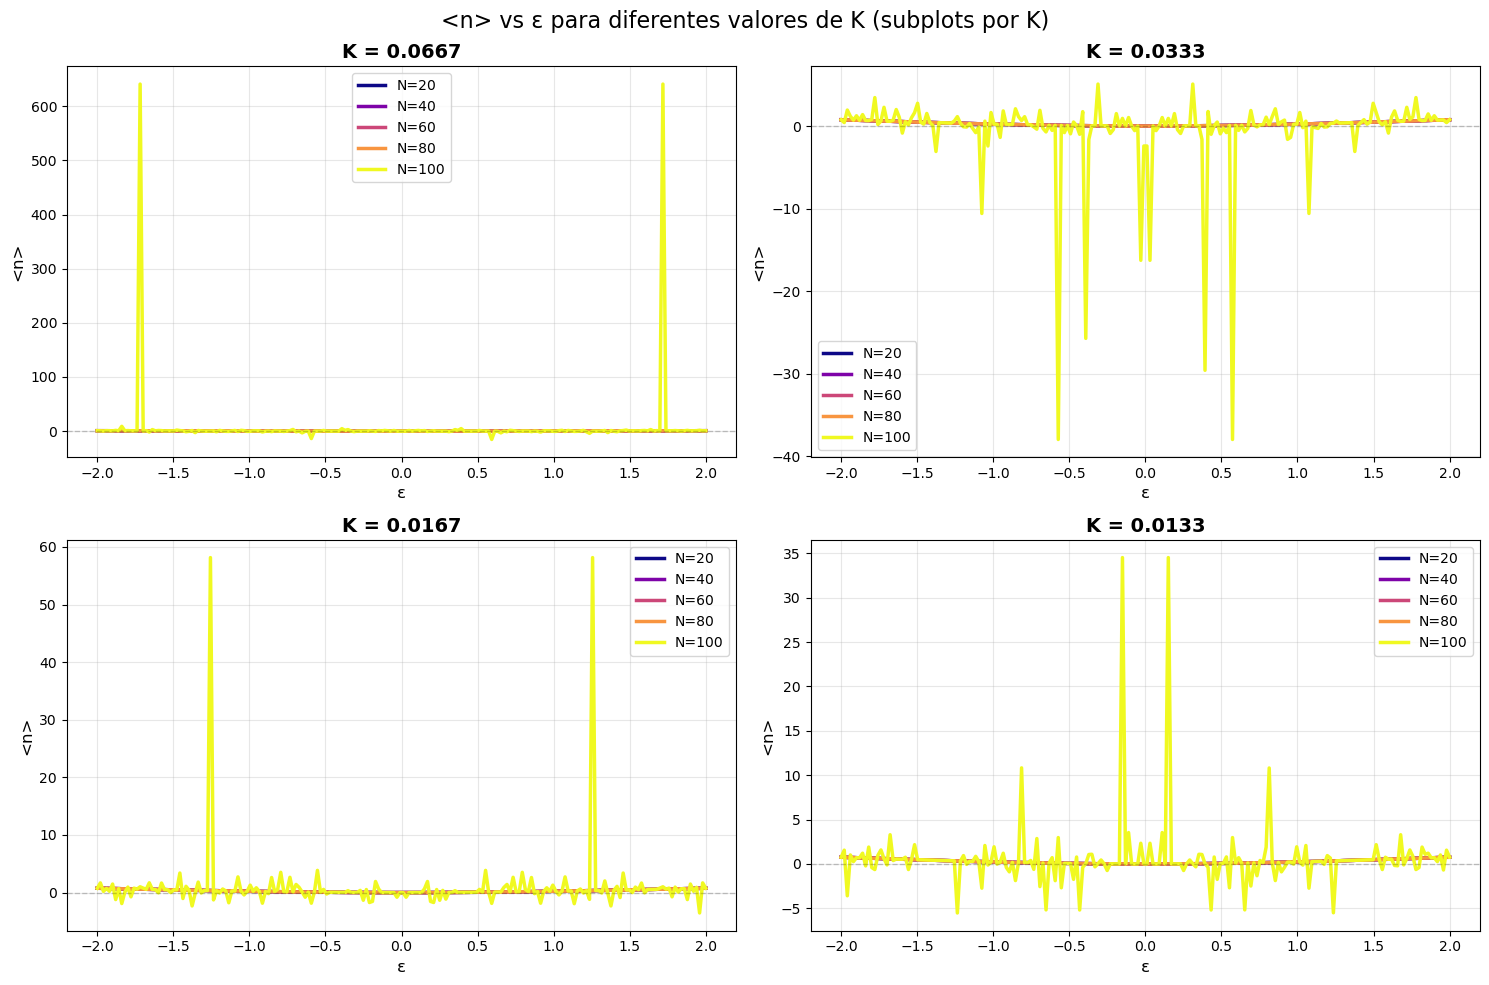

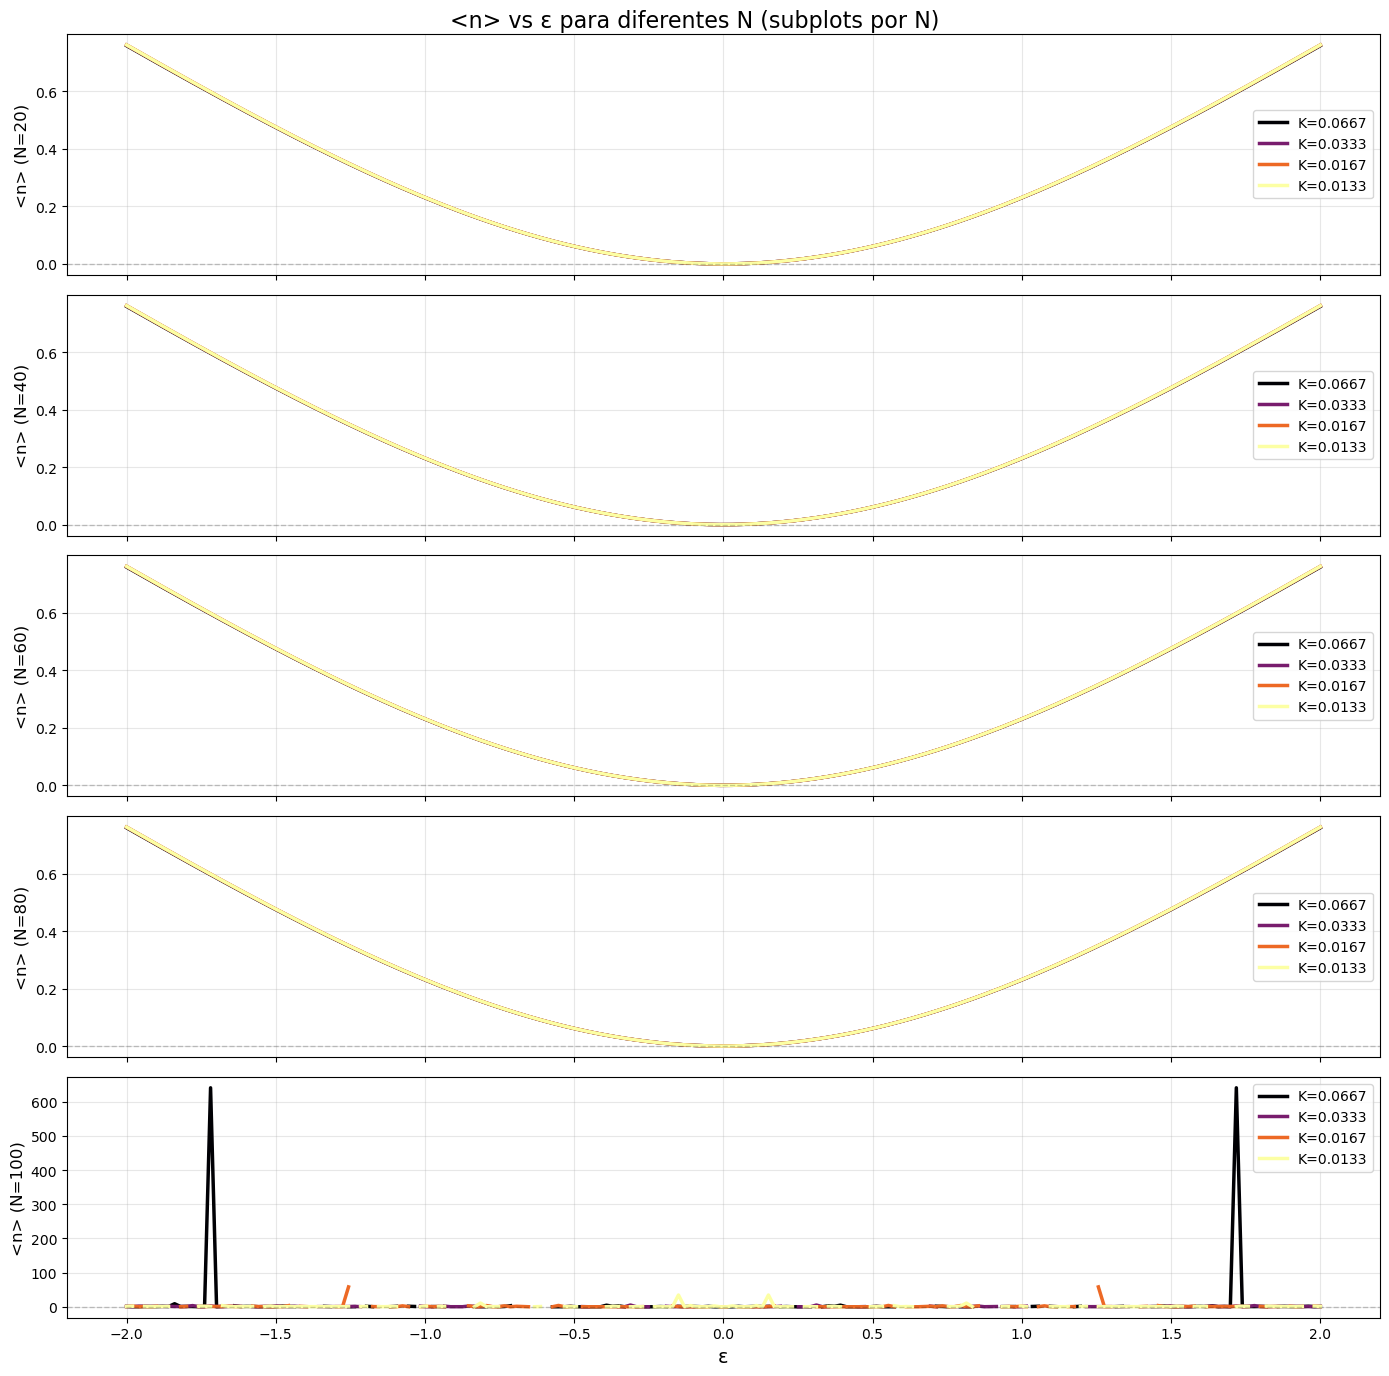

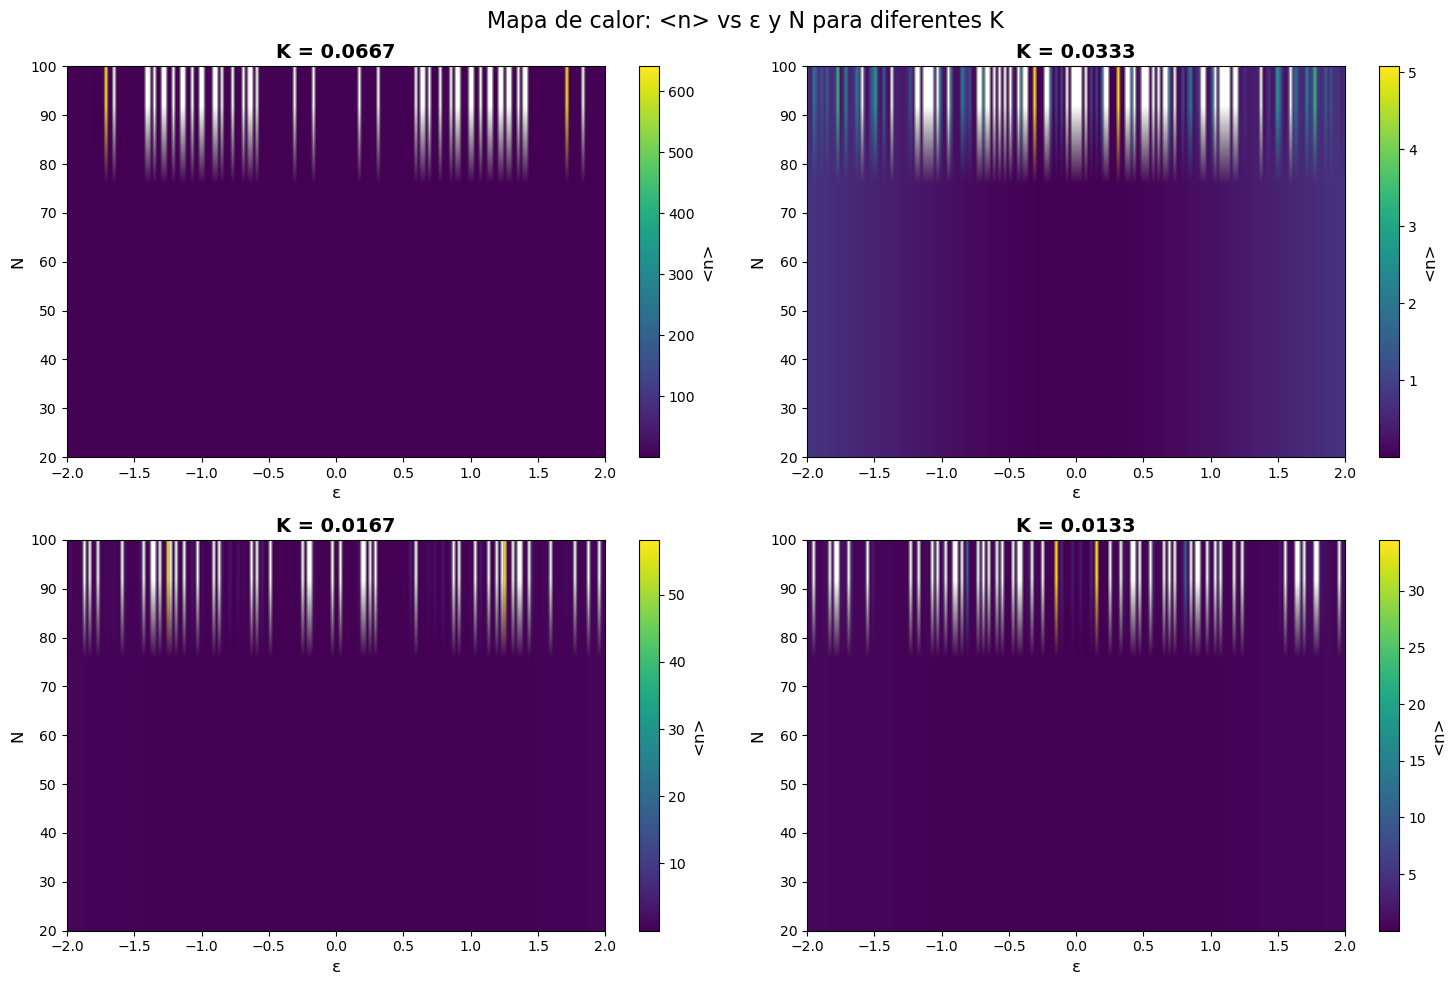

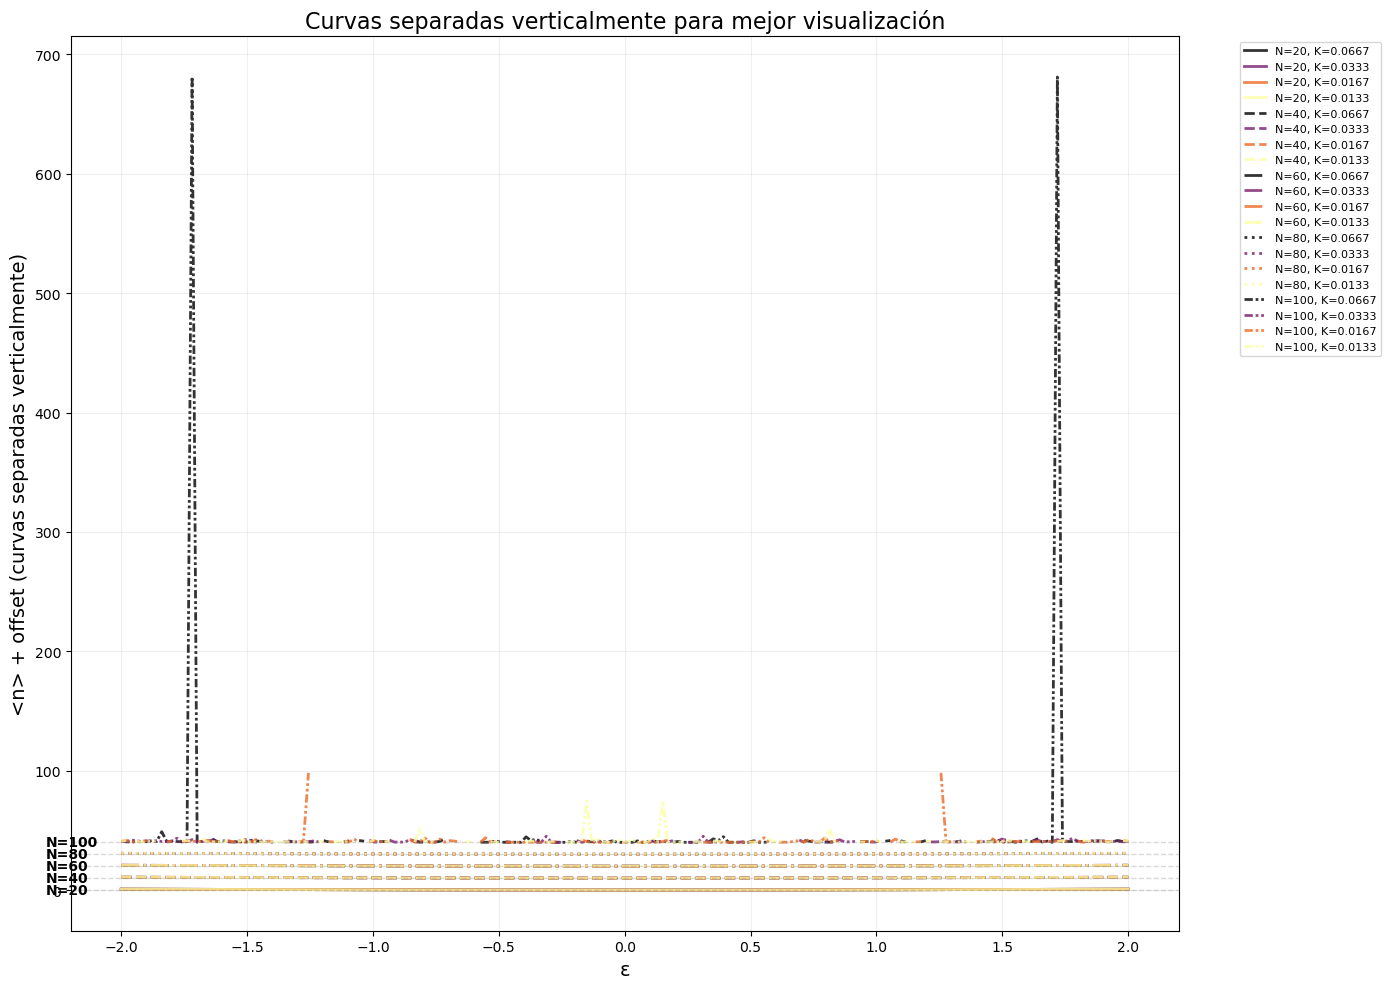

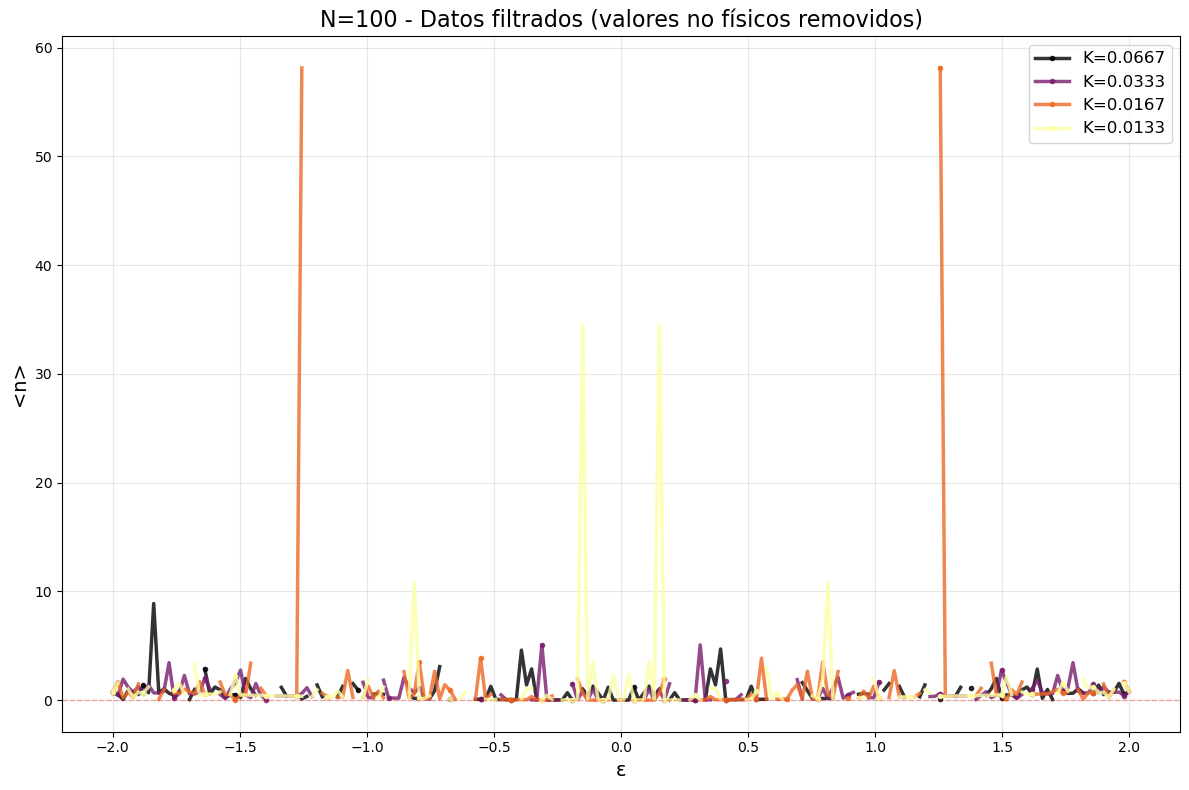

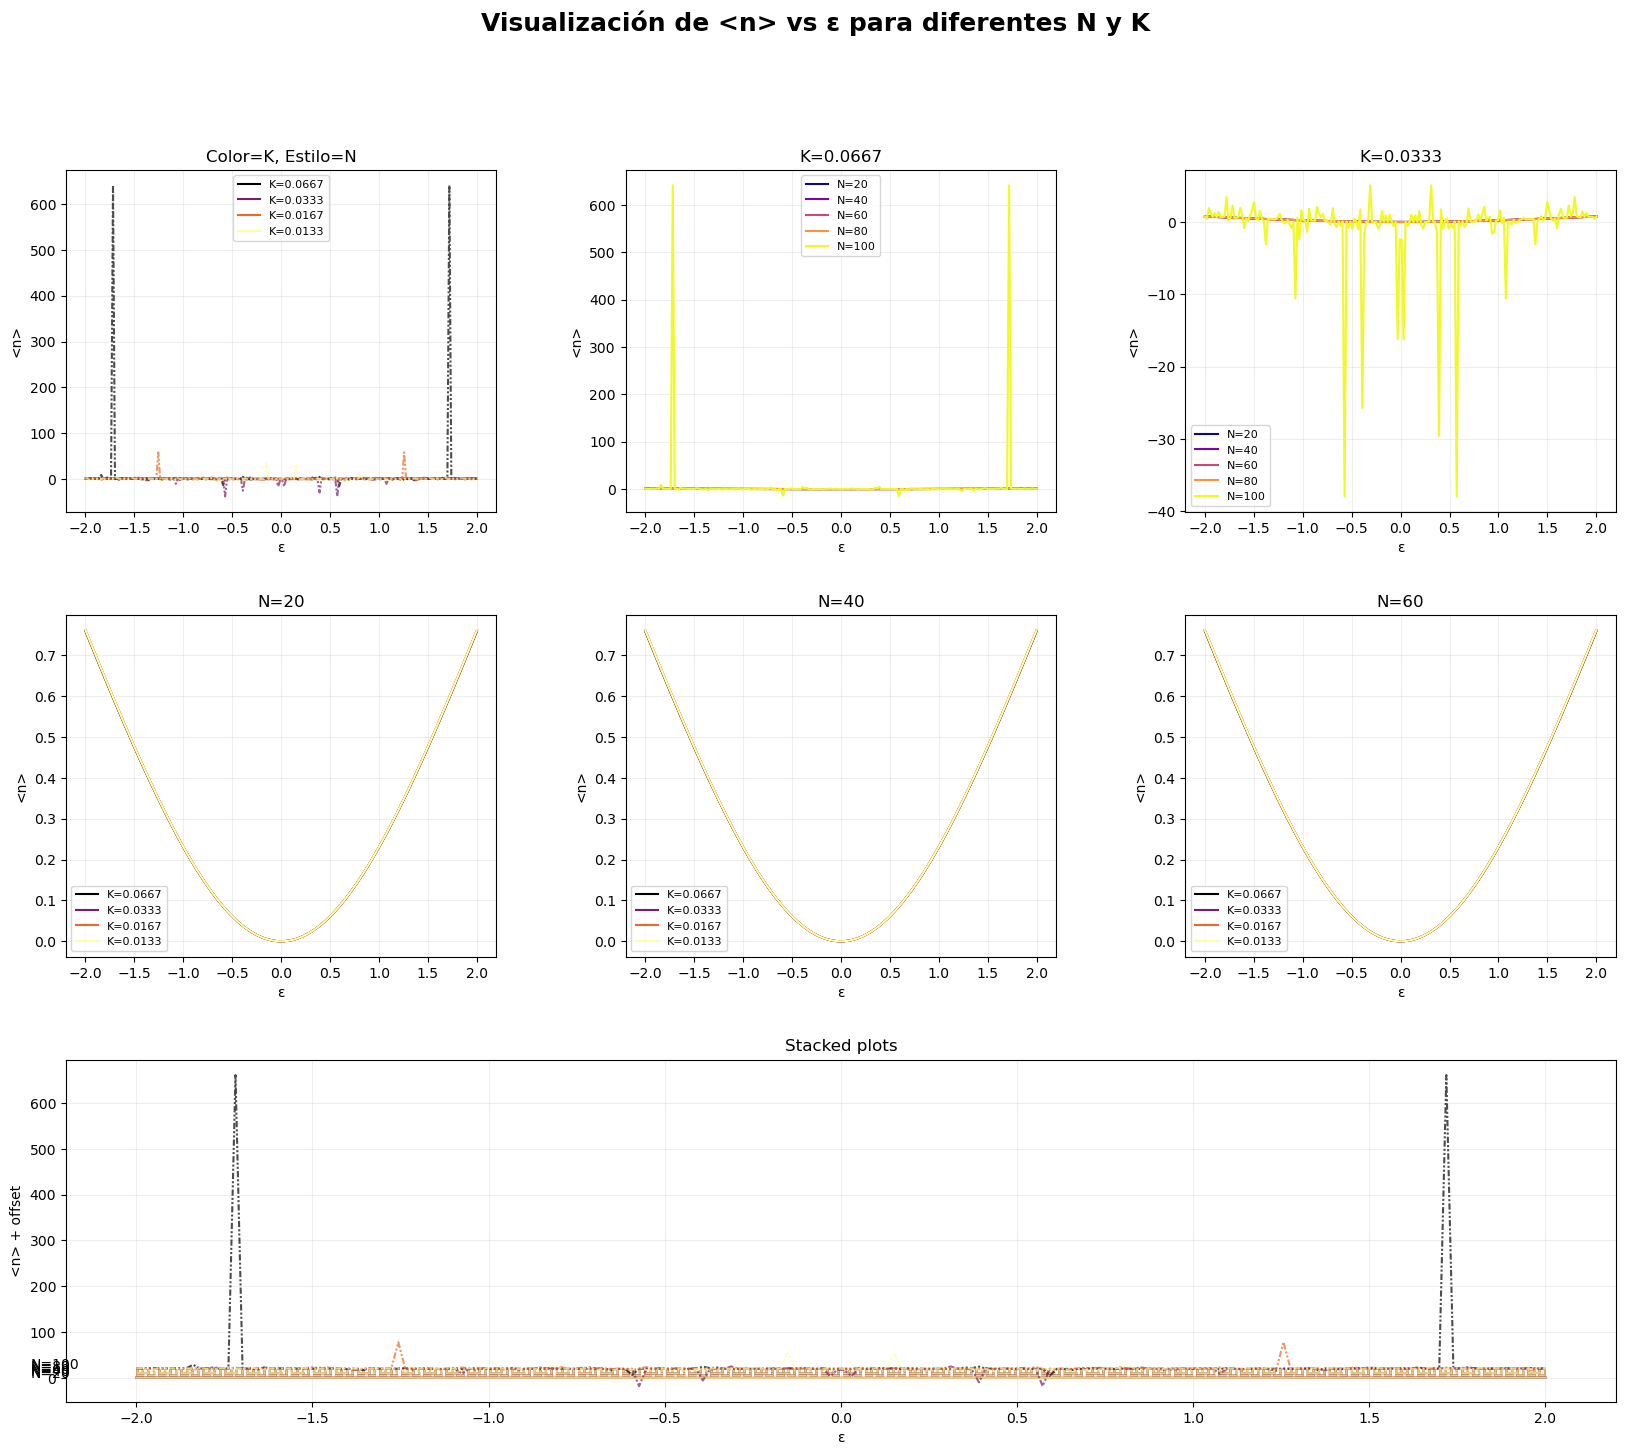

Todas las gráficas han sido guardadas en la carpeta '2photon/'


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Cargar los datos
cache_file = '2photon/NvsEpsi_data.npz'
data = np.load(cache_file, allow_pickle=True)

n_ss = data['n_ss']  # Shape: (len(N), len(K_list), len(epsi_list))
N_vals = data['N']
K_vals = data['K_list']
epsi_vals = data['epsi_list']

# ============================================================================
# OPCIÓN 1: Gráfica con diferentes colores para K y diferentes estilos para N
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

# Definir colores para K (usando un mapa de colores)
colors_K = plt.cm.viridis(np.linspace(0, 1, len(K_vals)))
# Definir estilos de línea para N
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1, 1, 1))]

for i, N in enumerate(N_vals):
    for j, K in enumerate(K_vals):
        # Crear etiqueta con N y K
        label = f'N={N}, K={K:.4f}'
        
        # Graficar con color según K y estilo según N
        ax.plot(epsi_vals, n_ss[i, j, :], 
               color=colors_K[j],
               linestyle=line_styles[i % len(line_styles)],
               linewidth=2,
               alpha=0.8,
               label=label)

ax.set_xlabel('ε (Squeezing)', fontsize=14)
ax.set_ylabel('<n>', fontsize=14)
ax.set_title('<n> vs ε para diferentes N y K (Color=K, Estilo=N)', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('2photon/nvsepsilon_color_by_K_style_by_N.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# OPCIÓN 2: Subplots separados por K (cada subplot tiene diferentes N)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

colors_N = plt.cm.plasma(np.linspace(0, 1, len(N_vals)))

for j, K in enumerate(K_vals):
    ax = axes[j]
    for i, N in enumerate(N_vals):
        ax.plot(epsi_vals, n_ss[i, j, :], 
               color=colors_N[i],
               linewidth=2.5,
               label=f'N={N}')
    
    ax.set_xlabel('ε', fontsize=12)
    ax.set_ylabel('<n>', fontsize=12)
    ax.set_title(f'K = {K:.4f}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    # Añadir línea en y=0 para referencia
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.2, linewidth=1)

plt.suptitle('<n> vs ε para diferentes valores de K (subplots por K)', fontsize=16)
plt.tight_layout()
plt.savefig('2photon/nvsepsilon_subplots_by_K.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# OPCIÓN 3: Subplots separados por N (cada subplot tiene diferentes K)
# ============================================================================
fig, axes = plt.subplots(len(N_vals), 1, figsize=(14, 14), sharex=True)

colors_K = plt.cm.inferno(np.linspace(0, 1, len(K_vals)))

for i, (ax, N) in enumerate(zip(axes, N_vals)):
    for j, K in enumerate(K_vals):
        # Filtrar valores negativos (problemas numéricos)
        y_data = n_ss[i, j, :]
        mask = y_data >= 0  # Solo valores físicos
        y_clean = np.ma.masked_where(~mask, y_data)
        
        ax.plot(epsi_vals, y_clean, 
               color=colors_K[j],
               linewidth=2.5,
               label=f'K={K:.4f}')
    
    ax.set_ylabel(f'<n> (N={N})', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.2, linewidth=1)

axes[-1].set_xlabel('ε', fontsize=14)
plt.suptitle('<n> vs ε para diferentes N (subplots por N)', fontsize=16)
plt.tight_layout()
plt.savefig('2photon/nvsepsilon_subplots_by_N.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# OPCIÓN 4: Mapa de calor para cada K (2D: N vs ε)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for j, K in enumerate(K_vals):
    ax = axes[j]
    
    # Crear matriz: filas = N, columnas = ε
    data_matrix = n_ss[:, j, :]
    
    # Enmascarar valores no físicos
    data_matrix_masked = np.ma.masked_where(data_matrix < 0, data_matrix)
    
    im = ax.imshow(data_matrix_masked, 
                   aspect='auto',
                   extent=[epsi_vals[0], epsi_vals[-1], N_vals[0], N_vals[-1]],
                   origin='lower',
                   cmap='viridis',
                   interpolation='bilinear')
    
    ax.set_xlabel('ε', fontsize=12)
    ax.set_ylabel('N', fontsize=12)
    ax.set_title(f'K = {K:.4f}', fontsize=14, fontweight='bold')
    
    # Añadir colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('<n>', fontsize=12)

plt.suptitle('Mapa de calor: <n> vs ε y N para diferentes K', fontsize=16)
plt.tight_layout()
plt.savefig('2photon/nvsepsilon_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# OPCIÓN 5: Gráfica separada verticalmente (stacked plots)
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 10))

# Definir offset vertical para separar curvas
offset_per_N = 10  # Separación entre diferentes N

for i, N in enumerate(N_vals):
    for j, K in enumerate(K_vals):
        # Añadir offset vertical
        y_offset = i * offset_per_N
        y_data = n_ss[i, j, :] + y_offset
        
        # Filtrar valores no físicos
        mask = (n_ss[i, j, :] >= -1e-6)  # Tolerancia pequeña
        y_data = np.ma.masked_where(~mask, y_data)
        
        ax.plot(epsi_vals, y_data,
               color=colors_K[j],
               linestyle=line_styles[i % len(line_styles)],
               linewidth=2,
               alpha=0.8,
               label=f'N={N}, K={K:.4f}')

# Añadir líneas horizontales para separar bloques de N
for i, N in enumerate(N_vals):
    y_offset = i * offset_per_N
    ax.axhline(y=y_offset, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    # Etiqueta en el eje y
    ax.text(epsi_vals[0] - 0.3, y_offset, f'N={N}', 
            verticalalignment='center', fontsize=10, fontweight='bold')

ax.set_xlabel('ε', fontsize=14)
ax.set_ylabel('<n> + offset (curvas separadas verticalmente)', fontsize=14)
ax.set_title('Curvas separadas verticalmente para mejor visualización', fontsize=16)
ax.grid(True, alpha=0.2)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('2photon/nvsepsilon_stacked.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# OPCIÓN 6: Solo N=100 con filtrado de datos no físicos
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Índice para N=100 (último elemento)
N_100_index = len(N_vals) - 1

for j, K in enumerate(K_vals):
    y_data = n_ss[N_100_index, j, :]
    
    # Filtrar valores no físicos (negativos o muy grandes)
    mask = (y_data >= 0) & (y_data < 100)  # Ajusta el límite superior según necesites
    y_clean = np.ma.masked_where(~mask, y_data)
    
    ax.plot(epsi_vals, y_clean, 
           color=colors_K[j],
           linewidth=2.5,
           marker='o',
           markersize=3,
           markevery=max(1, len(epsi_vals)//30),  # Marcar cada 30 puntos
           label=f'K={K:.4f}',
           alpha=0.8)

ax.set_xlabel('ε', fontsize=14)
ax.set_ylabel('<n>', fontsize=14)
ax.set_title('N=100 - Datos filtrados (valores no físicos removidos)', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=12)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=1)
plt.tight_layout()
plt.savefig('2photon/nvsepsilon_N100_filtered.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# OPCIÓN 7: Todas las opciones en una sola figura
# ============================================================================
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Subplot 1: Color por K, estilo por N
ax1 = fig.add_subplot(gs[0, 0])
for i, N in enumerate(N_vals):
    for j, K in enumerate(K_vals):
        ax1.plot(epsi_vals, n_ss[i, j, :], 
                color=colors_K[j], 
                linestyle=line_styles[i % len(line_styles)],
                linewidth=1.5,
                alpha=0.7)
ax1.set_xlabel('ε')
ax1.set_ylabel('<n>')
ax1.set_title('Color=K, Estilo=N')
ax1.grid(True, alpha=0.2)
# Leyenda pequeña
handles1 = []
for j, K in enumerate(K_vals):
    handles1.append(plt.Line2D([0], [0], color=colors_K[j], label=f'K={K:.4f}'))
ax1.legend(handles=handles1, fontsize=8, loc='best')

# Subplot 2: Subplots por K
ax2 = fig.add_subplot(gs[0, 1])
for i, N in enumerate(N_vals):
    ax2.plot(epsi_vals, n_ss[i, 0, :], color=colors_N[i], label=f'N={N}')
ax2.set_xlabel('ε')
ax2.set_ylabel('<n>')
ax2.set_title(f'K={K_vals[0]:.4f}')
ax2.grid(True, alpha=0.2)
ax2.legend(fontsize=8, loc='best')

ax3 = fig.add_subplot(gs[0, 2])
for i, N in enumerate(N_vals):
    ax3.plot(epsi_vals, n_ss[i, 1, :], color=colors_N[i], label=f'N={N}')
ax3.set_xlabel('ε')
ax3.set_ylabel('<n>')
ax3.set_title(f'K={K_vals[1]:.4f}')
ax3.grid(True, alpha=0.2)
ax3.legend(fontsize=8, loc='best')

# Subplot 3: Subplots por N
ax4 = fig.add_subplot(gs[1, 0])
for j, K in enumerate(K_vals):
    ax4.plot(epsi_vals, n_ss[0, j, :], color=colors_K[j], label=f'K={K:.4f}')
ax4.set_xlabel('ε')
ax4.set_ylabel('<n>')
ax4.set_title(f'N={N_vals[0]}')
ax4.grid(True, alpha=0.2)
ax4.legend(fontsize=8, loc='best')

ax5 = fig.add_subplot(gs[1, 1])
for j, K in enumerate(K_vals):
    ax5.plot(epsi_vals, n_ss[1, j, :], color=colors_K[j], label=f'K={K:.4f}')
ax5.set_xlabel('ε')
ax5.set_ylabel('<n>')
ax5.set_title(f'N={N_vals[1]}')
ax5.grid(True, alpha=0.2)
ax5.legend(fontsize=8, loc='best')

ax6 = fig.add_subplot(gs[1, 2])
for j, K in enumerate(K_vals):
    ax6.plot(epsi_vals, n_ss[2, j, :], color=colors_K[j], label=f'K={K:.4f}')
ax6.set_xlabel('ε')
ax6.set_ylabel('<n>')
ax6.set_title(f'N={N_vals[2]}')
ax6.grid(True, alpha=0.2)
ax6.legend(fontsize=8, loc='best')

# Subplot 4: Stacked
ax7 = fig.add_subplot(gs[2, :])
offset = 5
for i, N in enumerate(N_vals):
    for j, K in enumerate(K_vals):
        y_offset = i * offset
        ax7.plot(epsi_vals, n_ss[i, j, :] + y_offset,
                color=colors_K[j],
                linestyle=line_styles[i % len(line_styles)],
                linewidth=1.5,
                alpha=0.7)
    ax7.text(epsi_vals[0]-0.3, i*offset, f'N={N}', fontsize=10)

ax7.set_xlabel('ε')
ax7.set_ylabel('<n> + offset')
ax7.set_title('Stacked plots')
ax7.grid(True, alpha=0.2)

plt.suptitle('Visualización de <n> vs ε para diferentes N y K', fontsize=18, fontweight='bold')
plt.savefig('2photon/nvsepsilon_all_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Todas las gráficas han sido guardadas en la carpeta '2photon/'")

Cargando resultados desde caché...


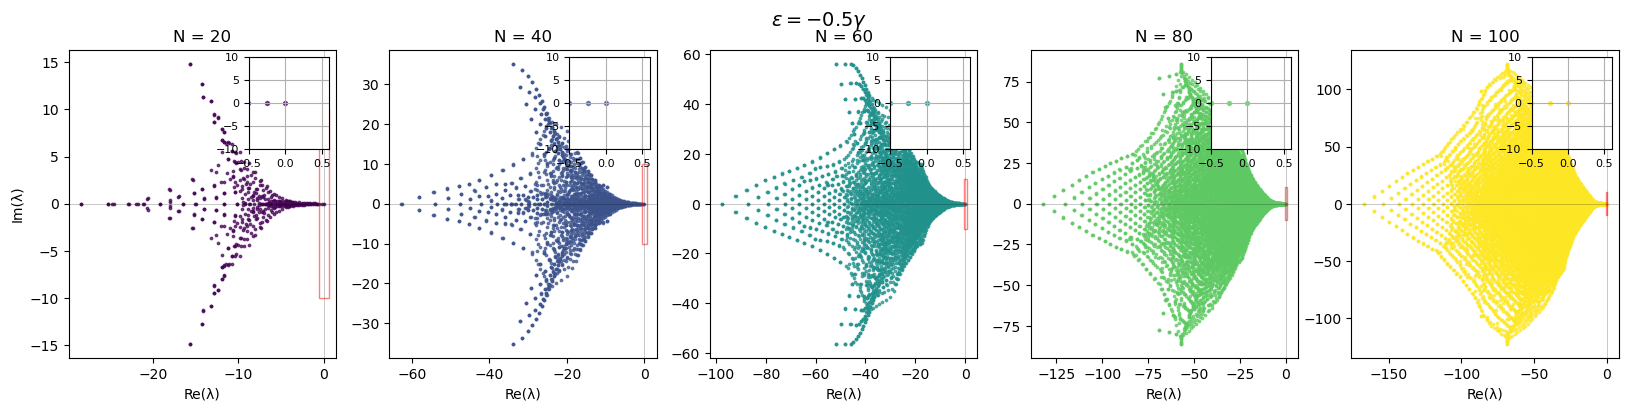

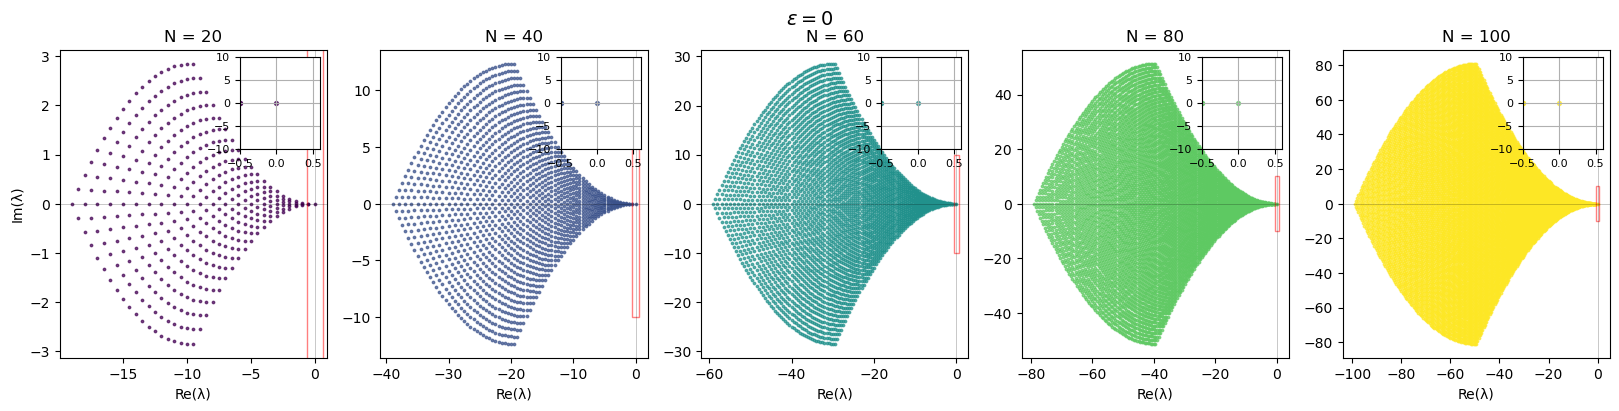

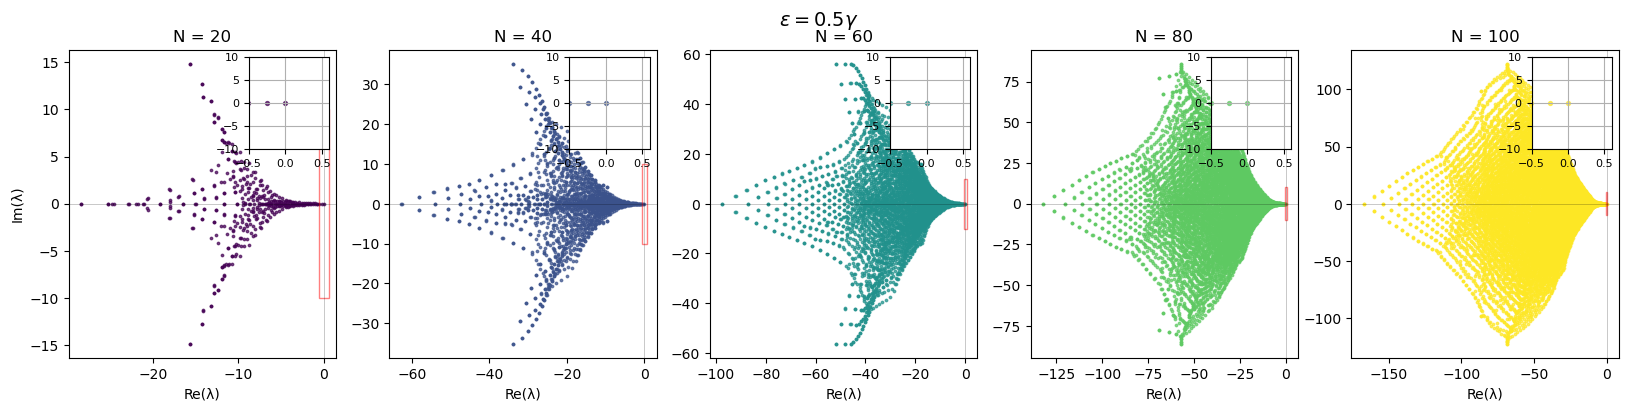

In [19]:
# Parámetros
N_values = [20, 40, 60, 80, 100]
g = 1.0
k = 1/60
Delta = 0
epsilon_values = [-0.5*g, 0.0*g, 0.5*g]
epsilon_labels = [r'$\epsilon = -0.5\gamma$', r'$\epsilon = 0$', r'$\epsilon = 0.5\gamma$']

# Archivo de caché ------------------------------------------------------------------------------------------------------------------------------------------------

cache_folder = '2photon'  # Carpeta
# Archivo de caché con extensión .qu
cache_file = os.path.join(cache_folder, 'eigenvalues_cache.qu.qu')

# Intentar cargar desde caché
if os.path.exists(cache_file):
    print("Cargando resultados desde caché...")
    results_cache = qload('2photon/eigenvalues_cache.qu')  
else:
    results_cache = {}
    print("Calculando eigenvalores (esto puede tomar un momento)...")
    start_time = time.time()
    
    for eps in epsilon_values:
        for N in N_values:
            key = f"N{N}_eps{eps}"
            salto = [np.sqrt(g) * destroy(N)]
            eigs = Kerr_Diag(N, Delta, k, eps, salto)
            results_cache[key] = eigs
            print(f"  N={N}, eps={eps/g:.1f}g - listo")
    
    elapsed_time = time.time() - start_time
    print(f"Tiempo de cálculo: {elapsed_time:.2f} segundos")
    
    # Guardar en caché
    qsave(results_cache, cache_file)

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Crear figura - Una figura por cada valor de epsilon
for idx, (eps, label) in enumerate(zip(epsilon_values, epsilon_labels)):
    # Crear una figura con 5 subplots (una por cada N)
    fig, axes = plt.subplots(1, len(N_values), figsize=(20, 4))
    fig.suptitle(label, fontsize=14)
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(N_values)))
    
    for i, N in enumerate(N_values):
        ax = axes[i]
        
        # Obtener eigenvalores del caché
        key = f"N{N}_eps{eps}"
        eigs = results_cache[key]
        
        X = np.real(eigs)
        Y = np.imag(eigs)
        
        ax.scatter(X, Y, s=3, c=[colors[i]], alpha=0.7, rasterized=True)
        
        ax.set_title(f'N = {N}', fontsize=12)
        ax.set_xlabel('Re(λ)', fontsize=10)
        if i == 0:
            ax.set_ylabel('Im(λ)', fontsize=10)
        
        ax.axhline(0, color='black', lw=0.5, alpha=0.3)
        ax.axvline(0, color='black', lw=0.5, alpha=0.3)
        
        # Opcional: ajustar límites si es necesario
        # ax.set_xlim([-20, 5])
        # ax.set_ylim([-50, 50])
        
        # Agregar zoom si quieres mantenerlo
        axins = inset_axes(ax, width="30%", height="30%", loc='upper right')
        mask = (X > -1.5) & (X < 1.5) & (Y > -15) & (Y < 15)
        if np.any(mask):
            axins.scatter(X[mask], Y[mask], s=8, c=[colors[i]], alpha=0.7)
        
        axins.set_xlim(-0.5, 0.6)
        axins.set_ylim(-10, 10)
        axins.grid(0.5)
        axins.tick_params(axis='both', labelsize=8)
        
        #axins.set_xticks([-2, -1.5, -1, -0.5, 0])
        axins.set_yticks([-10, -5, 0, 5, 10])
        
        # Indicador de zona de zoom
        from matplotlib.patches import Rectangle
        rect = Rectangle((-0.6, -10), 1.2, 20, 
                         linewidth=1, edgecolor='red', facecolor='none', alpha=0.5)
        ax.add_patch(rect)
    

    plt.savefig(f'2photon/eigsKerr_epsilon_{idx+1}.pdf', dpi=300)
    plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


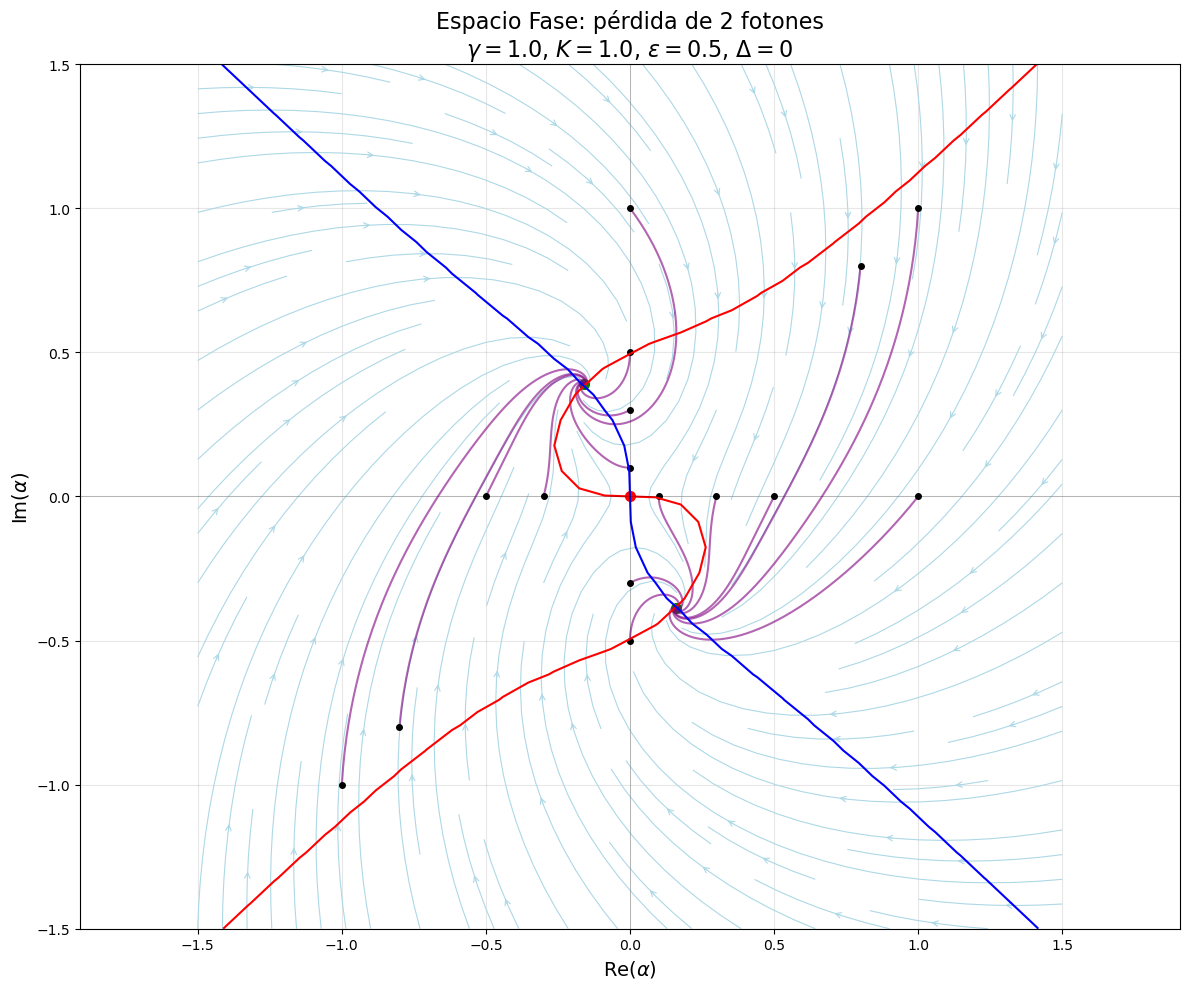

PUNTOS FIJOS - PÉRDIDA DE DOS FOTONES
Trivial:
  α = 0.000000+0.000000j
  |α| = 0.000000
  n = |α|² = 0.000000
  θ = 0.000000 rad

No trivial 1:
  α = 0.160899-0.388443j
  |α| = 0.420448
  n = |α|² = 0.176777
  θ = -1.178097 rad

No trivial 2:
  α = -0.160899+0.388443j
  |α| = 0.420448
  n = |α|² = 0.176777
  θ = 1.963495 rad

RESULTADO ANALITICO DE CAMPO MEDIO
n_MF = epsilon / (2 sqrt(K² + gamma²))
n_MF = 0.176777
|alpha_MF| = 0.420448


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


# ============================================
# PARAMETROS DEL SISTEMA
# ============================================

gamma = 1.0      # Tasa de pérdida de DOS fotones
k = 1.0          # No linealidad Kerr
epsilon = 0.5    # Driving paramétrico

# Delta = 0


# ============================================
# SISTEMA DE ECUACIONES DE CAMPO MEDIO
# ============================================

def sistema(y, t, gamma, k, epsilon):

    x, y_im = y

    alpha = x + 1j*y_im

    n = np.abs(alpha)**2

    # Ecuación de campo medio:
    #
    # d alpha/dt =
    # -(gamma + i k)|alpha|^2 alpha
    # - i epsilon/2 alpha*

    dalpha_dt = (
        -(gamma + 1j*k)*n*alpha
        - 1j*epsilon/2*np.conj(alpha)
    )

    return [
        np.real(dalpha_dt),
        np.imag(dalpha_dt)
    ]


# ============================================
# PUNTOS FIJOS
# ============================================

def puntos_fijos(gamma, k, epsilon):

    puntos = []

    # ----------------------------------------
    # Punto fijo trivial
    # ----------------------------------------

    puntos.append(
        (0.0, 0.0, 'Trivial')
    )

    # ----------------------------------------
    # Puntos fijos no triviales
    #
    # n = epsilon/(2 sqrt(k^2 + gamma^2))
    # ----------------------------------------

    n = epsilon / (2*np.sqrt(k**2 + gamma**2))

    r = np.sqrt(n)

    # Para el estado estacionario:
    #
    # cos(2 theta) = -k/sqrt(k^2 + gamma^2)
    #
    # sin(2 theta) = -gamma/sqrt(k^2 + gamma^2)

    theta = 0.5 * np.arctan2(
        -gamma,
        -k
    )

    # Soluciones relacionadas por Z2:
    # alpha -> -alpha

    alpha1 = r * np.exp(1j*theta)
    alpha2 = -alpha1

    puntos.append(
        (np.real(alpha1),
         np.imag(alpha1),
         'No trivial 1')
    )

    puntos.append(
        (np.real(alpha2),
         np.imag(alpha2),
         'No trivial 2')
    )

    return puntos


# ============================================
# CAMPO VECTORIAL
# ============================================

def campo_vectorial(X, Y, gamma, k, epsilon):

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):

            alpha = X[i,j] + 1j*Y[i,j]

            n = np.abs(alpha)**2

            dalpha_dt = (
                -(gamma + 1j*k)*n*alpha
                - 1j*epsilon/2*np.conj(alpha)
            )

            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)

    return U, V


# ============================================
# TRAYECTORIA
# ============================================

def trayectoria(alpha0, gamma, k, epsilon,
                t_max=20, n_points=1000):

    t = np.linspace(0, t_max, n_points)

    X_0 = np.real(alpha0)
    Y_0 = np.imag(alpha0)

    sol = odeint(
        sistema,
        [X_0, Y_0],
        t,
        args=(gamma, k, epsilon)
    )

    trayectoria_complex = sol[:,0] + 1j*sol[:,1]

    return trayectoria_complex, t


# ============================================
# NULCLINAS
# ============================================

def nulclinas(X, Y, gamma, k, epsilon):

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):

            alpha = X[i,j] + 1j*Y[i,j]

            n = np.abs(alpha)**2

            dalpha_dt = (
                -(gamma + 1j*k)*n*alpha
                - 1j*epsilon/2*np.conj(alpha)
            )

            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)

    return U, V


# ============================================
# CONFIGURACION DE LA GRAFICA
# ============================================

plt.figure(figsize=(12,10))

lim = 1.5

x = np.linspace(-lim, lim, 35)
y = np.linspace(-lim, lim, 35)

X, Y = np.meshgrid(x, y)


# ============================================
# CAMPO VECTORIAL
# ============================================

U, V = campo_vectorial(
    X, Y,
    gamma,
    k,
    epsilon
)

plt.streamplot(
    X, Y,
    U, V,
    color='lightblue',
    linewidth=0.8,
    density=1.2,
    arrowstyle='->',
    arrowsize=1.0
)


# ============================================
# PUNTOS FIJOS
# ============================================

puntos = puntos_fijos(
    gamma,
    k,
    epsilon
)

for xp, yp, label in puntos:

    if 'Trivial' in label:

        plt.plot(
            xp, yp,
            'ro',
            markersize=7,
            label=label
        )

    else:

        plt.plot(
            xp, yp,
            'go',
            markersize=7,
            label=label
        )


# ============================================
# TRAYECTORIAS
# ============================================

ini_con = [

    0.1 + 0.0j,
    0.0 + 0.1j,

    0.3 + 0.0j,
    0.0 + 0.3j,

    -0.3 + 0.0j,
    0.0 - 0.3j,

    0.5 + 0.0j,
    0.0 + 0.5j,

    -0.5 + 0.0j,
    0.0 - 0.5j,

    0.8 + 0.8j,
    -0.8 - 0.8j,

    1.0 + 0.0j,
    0.0 + 1.0j,

    1.0 + 1.0j,
    -1.0 - 1.0j
]


for alpha0 in ini_con:

    tray, t = trayectoria(
        alpha0,
        gamma,
        k,
        epsilon,
        t_max=30,
        n_points=2000
    )

    plt.plot(
        np.real(tray),
        np.imag(tray),
        color='purple',
        alpha=0.6,
        linewidth=1.5
    )

    # Punto inicial

    plt.plot(
        np.real(alpha0),
        np.imag(alpha0),
        'k.',
        markersize=8
    )


# ============================================
# NULCLINAS
# ============================================

U, V = nulclinas(
    X, Y,
    gamma,
    k,
    epsilon
)

# U = 0
plt.contour(
    X, Y, U,
    levels=[0],
    colors='red',
    linewidths=1.5
)

# V = 0
plt.contour(
    X, Y, V,
    levels=[0],
    colors='blue',
    linewidths=1.5
)


# ============================================
# EJES
# ============================================

plt.axhline(
    0,
    color='black',
    linewidth=0.5,
    alpha=0.3
)

plt.axvline(
    0,
    color='black',
    linewidth=0.5,
    alpha=0.3
)


# ============================================
# ETIQUETAS
# ============================================

plt.xlabel(
    r'Re($\alpha$)',
    fontsize=14
)

plt.ylabel(
    r'Im($\alpha$)',
    fontsize=14
)

plt.title(
    f'Espacio Fase: pérdida de 2 fotones\n'
    f'$\\gamma={gamma}$, $K={k}$, '
    f'$\\epsilon={epsilon}$, $\\Delta=0$',
    fontsize=16
)

plt.grid(
    True,
    alpha=0.3
)

plt.axis('equal')

plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.tight_layout()

plt.savefig('PhaseSpace2ph.pdf')
plt.show()


# ============================================
# INFORMACION DE LOS PUNTOS FIJOS
# ============================================

print("="*60)
print("PUNTOS FIJOS - PÉRDIDA DE DOS FOTONES")
print("="*60)

for xp, yp, label in puntos:

    alpha = xp + 1j*yp

    r = np.abs(alpha)
    n = r**2
    theta = np.angle(alpha)

    print(f"{label}:")
    print(f"  α = {alpha:.6f}")
    print(f"  |α| = {r:.6f}")
    print(f"  n = |α|² = {n:.6f}")
    print(f"  θ = {theta:.6f} rad")
    print()


# ============================================
# RESULTADO ANALITICO
# ============================================

n_mf = epsilon / (
    2*np.sqrt(k**2 + gamma**2)
)

print("="*60)
print("RESULTADO ANALITICO DE CAMPO MEDIO")
print("="*60)

print(
    f"n_MF = epsilon / "
    f"(2 sqrt(K² + gamma²))"
)

print(
    f"n_MF = {n_mf:.6f}"
)

print(
    f"|alpha_MF| = {np.sqrt(n_mf):.6f}"
)

C:\Users\Arturo\AppData\Local\Temp\ipykernel_25308\559722500.py:70: RuntimeWarning: invalid value encountered in sqrt
  r = np.sqrt(n)
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


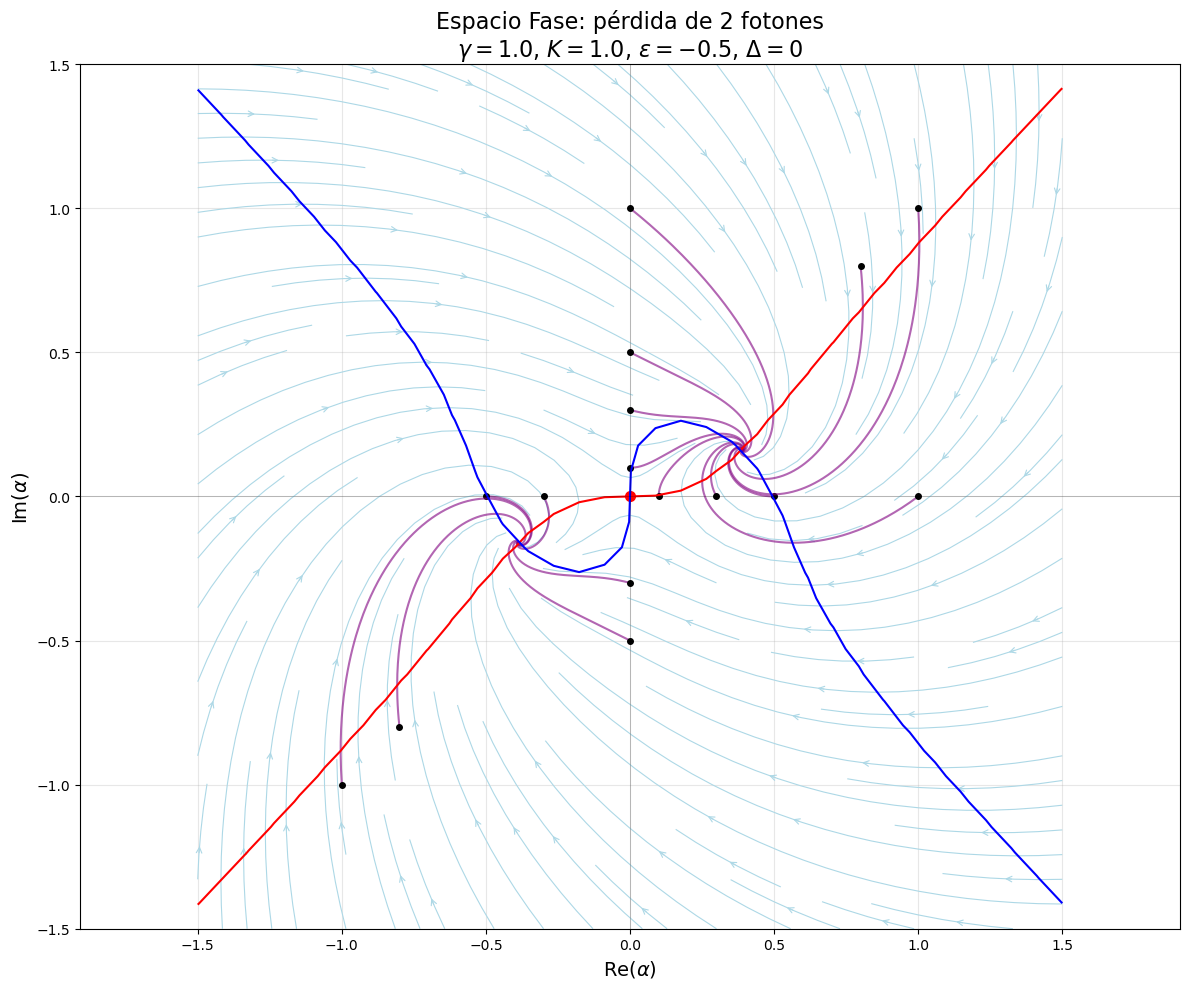

PUNTOS FIJOS - PÉRDIDA DE DOS FOTONES
Trivial:
  α = 0.000000+0.000000j
  |α| = 0.000000
  n = |α|² = 0.000000
  θ = 0.000000 rad

No trivial 1:
  α = nan+nanj
  |α| = nan
  n = |α|² = nan
  θ = nan rad

No trivial 2:
  α = nan+nanj
  |α| = nan
  n = |α|² = nan
  θ = nan rad

RESULTADO ANALITICO DE CAMPO MEDIO
n_MF = epsilon / (2 sqrt(K² + gamma²))
n_MF = -0.176777
|alpha_MF| = nan


C:\Users\Arturo\AppData\Local\Temp\ipykernel_25308\559722500.py:440: RuntimeWarning: invalid value encountered in sqrt
  f"|alpha_MF| = {np.sqrt(n_mf):.6f}"


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


# ============================================
# PARAMETROS DEL SISTEMA
# ============================================

gamma = 1.0      # Tasa de pérdida de DOS fotones
k = 1.0          # No linealidad Kerr
epsilon = -0.5    # Driving paramétrico

# Delta = 0


# ============================================
# SISTEMA DE ECUACIONES DE CAMPO MEDIO
# ============================================

def sistema(y, t, gamma, k, epsilon):

    x, y_im = y

    alpha = x + 1j*y_im

    n = np.abs(alpha)**2

    # Ecuación de campo medio:
    #
    # d alpha/dt =
    # -(gamma + i k)|alpha|^2 alpha
    # - i epsilon/2 alpha*

    dalpha_dt = (
        -(gamma + 1j*k)*n*alpha
        - 1j*epsilon/2*np.conj(alpha)
    )

    return [
        np.real(dalpha_dt),
        np.imag(dalpha_dt)
    ]


# ============================================
# PUNTOS FIJOS
# ============================================

def puntos_fijos(gamma, k, epsilon):

    puntos = []

    # ----------------------------------------
    # Punto fijo trivial
    # ----------------------------------------

    puntos.append(
        (0.0, 0.0, 'Trivial')
    )

    # ----------------------------------------
    # Puntos fijos no triviales
    #
    # n = epsilon/(2 sqrt(k^2 + gamma^2))
    # ----------------------------------------

    n = epsilon / (2*np.sqrt(k**2 + gamma**2))

    r = np.sqrt(n)

    # Para el estado estacionario:
    #
    # cos(2 theta) = -k/sqrt(k^2 + gamma^2)
    #
    # sin(2 theta) = -gamma/sqrt(k^2 + gamma^2)

    theta = 0.5 * np.arctan2(
        -gamma,
        -k
    )

    # Soluciones relacionadas por Z2:
    # alpha -> -alpha

    alpha1 = r * np.exp(1j*theta)
    alpha2 = -alpha1

    puntos.append(
        (np.real(alpha1),
         np.imag(alpha1),
         'No trivial 1')
    )

    puntos.append(
        (np.real(alpha2),
         np.imag(alpha2),
         'No trivial 2')
    )

    return puntos


# ============================================
# CAMPO VECTORIAL
# ============================================

def campo_vectorial(X, Y, gamma, k, epsilon):

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):

            alpha = X[i,j] + 1j*Y[i,j]

            n = np.abs(alpha)**2

            dalpha_dt = (
                -(gamma + 1j*k)*n*alpha
                - 1j*epsilon/2*np.conj(alpha)
            )

            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)

    return U, V


# ============================================
# TRAYECTORIA
# ============================================

def trayectoria(alpha0, gamma, k, epsilon,
                t_max=20, n_points=1000):

    t = np.linspace(0, t_max, n_points)

    X_0 = np.real(alpha0)
    Y_0 = np.imag(alpha0)

    sol = odeint(
        sistema,
        [X_0, Y_0],
        t,
        args=(gamma, k, epsilon)
    )

    trayectoria_complex = sol[:,0] + 1j*sol[:,1]

    return trayectoria_complex, t


# ============================================
# NULCLINAS
# ============================================

def nulclinas(X, Y, gamma, k, epsilon):

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):

            alpha = X[i,j] + 1j*Y[i,j]

            n = np.abs(alpha)**2

            dalpha_dt = (
                -(gamma + 1j*k)*n*alpha
                - 1j*epsilon/2*np.conj(alpha)
            )

            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)

    return U, V


# ============================================
# CONFIGURACION DE LA GRAFICA
# ============================================

plt.figure(figsize=(12,10))

lim = 1.5

x = np.linspace(-lim, lim, 35)
y = np.linspace(-lim, lim, 35)

X, Y = np.meshgrid(x, y)


# ============================================
# CAMPO VECTORIAL
# ============================================

U, V = campo_vectorial(
    X, Y,
    gamma,
    k,
    epsilon
)

plt.streamplot(
    X, Y,
    U, V,
    color='lightblue',
    linewidth=0.8,
    density=1.2,
    arrowstyle='->',
    arrowsize=1.0
)


# ============================================
# PUNTOS FIJOS
# ============================================

puntos = puntos_fijos(
    gamma,
    k,
    epsilon
)

for xp, yp, label in puntos:

    if 'Trivial' in label:

        plt.plot(
            xp, yp,
            'ro',
            markersize=7,
            label=label
        )

    else:

        plt.plot(
            xp, yp,
            'go',
            markersize=7,
            label=label
        )


# ============================================
# TRAYECTORIAS
# ============================================

ini_con = [

    0.1 + 0.0j,
    0.0 + 0.1j,

    0.3 + 0.0j,
    0.0 + 0.3j,

    -0.3 + 0.0j,
    0.0 - 0.3j,

    0.5 + 0.0j,
    0.0 + 0.5j,

    -0.5 + 0.0j,
    0.0 - 0.5j,

    0.8 + 0.8j,
    -0.8 - 0.8j,

    1.0 + 0.0j,
    0.0 + 1.0j,

    1.0 + 1.0j,
    -1.0 - 1.0j
]


for alpha0 in ini_con:

    tray, t = trayectoria(
        alpha0,
        gamma,
        k,
        epsilon,
        t_max=30,
        n_points=2000
    )

    plt.plot(
        np.real(tray),
        np.imag(tray),
        color='purple',
        alpha=0.6,
        linewidth=1.5
    )

    # Punto inicial

    plt.plot(
        np.real(alpha0),
        np.imag(alpha0),
        'k.',
        markersize=8
    )


# ============================================
# NULCLINAS
# ============================================

U, V = nulclinas(
    X, Y,
    gamma,
    k,
    epsilon
)

# U = 0
plt.contour(
    X, Y, U,
    levels=[0],
    colors='red',
    linewidths=1.5
)

# V = 0
plt.contour(
    X, Y, V,
    levels=[0],
    colors='blue',
    linewidths=1.5
)


# ============================================
# EJES
# ============================================

plt.axhline(
    0,
    color='black',
    linewidth=0.5,
    alpha=0.3
)

plt.axvline(
    0,
    color='black',
    linewidth=0.5,
    alpha=0.3
)


# ============================================
# ETIQUETAS
# ============================================

plt.xlabel(
    r'Re($\alpha$)',
    fontsize=14
)

plt.ylabel(
    r'Im($\alpha$)',
    fontsize=14
)

plt.title(
    f'Espacio Fase: pérdida de 2 fotones\n'
    f'$\\gamma={gamma}$, $K={k}$, '
    f'$\\epsilon={epsilon}$, $\\Delta=0$',
    fontsize=16
)

plt.grid(
    True,
    alpha=0.3
)

plt.axis('equal')

plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.tight_layout()

plt.savefig('PhaseSpace2ph.pdf')
plt.show()


# ============================================
# INFORMACION DE LOS PUNTOS FIJOS
# ============================================

print("="*60)
print("PUNTOS FIJOS - PÉRDIDA DE DOS FOTONES")
print("="*60)

for xp, yp, label in puntos:

    alpha = xp + 1j*yp

    r = np.abs(alpha)
    n = r**2
    theta = np.angle(alpha)

    print(f"{label}:")
    print(f"  α = {alpha:.6f}")
    print(f"  |α| = {r:.6f}")
    print(f"  n = |α|² = {n:.6f}")
    print(f"  θ = {theta:.6f} rad")
    print()


# ============================================
# RESULTADO ANALITICO
# ============================================

n_mf = epsilon / (
    2*np.sqrt(k**2 + gamma**2)
)

print("="*60)
print("RESULTADO ANALITICO DE CAMPO MEDIO")
print("="*60)

print(
    f"n_MF = epsilon / "
    f"(2 sqrt(K² + gamma²))"
)

print(
    f"n_MF = {n_mf:.6f}"
)

print(
    f"|alpha_MF| = {np.sqrt(n_mf):.6f}"
)